# Etapa 5 — Modelos de Machine Learning

---
> Conjunto de datos obtenido del Servicio Sismológico Nacional, adscrito al Instituto de Geofísica de la Universidad Nacional Autónoma de México


El Omori de la Etapa 4 es un *oráculo*: ajusta sus parámetros con toda la secuencia (hasta 365 días) y luego evalúa sobre las mismas 24h que ya vio. Los modelos ML aquí usan solo la primera hora de actividad post-sismo, lo que es una tarea más difícil y más realista.

**Modelos entrenados:**
- Random Forest (RF)
- XGBoost (XGB)

**Targets:**
- Modelo 1 (prioritario): `n_replicas_24h` — conteo de réplicas sobre Mc en 24h
- Modelo 2: `mag_max_48h` — magnitud máxima de réplica en 48h

**Validación:** bloques temporales (train en pasado -> test en futuro)

In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import OrdinalEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import cross_val_predict, KFold
import xgboost as xgb
import joblib
from pathlib import Path

In [46]:
mainshocks = pd.read_parquet('mainshocks.parquet')
omori      = pd.read_parquet('omori_params.parquet')

mainshocks['datetime_utc'] = pd.to_datetime(mainshocks['datetime_utc'])

# Ordenar por tiempo — imprescindible para validación por bloques temporales
mainshocks = mainshocks.sort_values('datetime_utc').reset_index(drop=True)

print(f'Corpus: {len(mainshocks)} mainshocks')
print(f'Rango: {mainshocks["datetime_utc"].min().date()} -> {mainshocks["datetime_utc"].max().date()}')

Corpus: 305 mainshocks
Rango: 1974-05-31 -> 2026-01-02


In [47]:
# Codificación ordinal de categoria_prof (orden físico de profundidad)
orden_prof = [['Superficial', 'Intermedio', 'Profundo', 'Desconocida']]
enc = OrdinalEncoder(categories=orden_prof, handle_unknown='use_encoded_value', unknown_value=-1)
mainshocks['prof_cod'] = enc.fit_transform(mainshocks[['categoria_prof']])

# Features del mainshock en t=0
FEAT_T0 = ['magnitud', 'profundidad', 'latitud', 'longitud', 'prof_cod', 'hora_local', 'Mc_epoca']

# Features de actividad temprana (primera hora)
FEAT_1H = ['n_replicas_1h', 'mag_max_1h', 'tasa_1h']

FEATURES = FEAT_T0 + FEAT_1H

# Targets
TARGET_1 = 'n_replicas_24h'
TARGET_2 = 'mag_max_48h'

# Imputar mag_max_1h = 0 cuando no hubo réplicas en la primera hora
mainshocks['mag_max_1h'] = mainshocks['mag_max_1h'].fillna(0)

X = mainshocks[FEATURES].copy()
y1 = mainshocks[TARGET_1].values.astype(float)
y2 = mainshocks[TARGET_2].fillna(0).values.astype(float)

print(f'Features: {FEATURES}')
print(f'Shape X: {X.shape}')
print(f'\nDistribución de {TARGET_1}:')
print(pd.Series(y1).describe().round(2))

Features: ['magnitud', 'profundidad', 'latitud', 'longitud', 'prof_cod', 'hora_local', 'Mc_epoca', 'n_replicas_1h', 'mag_max_1h', 'tasa_1h']
Shape X: (305, 10)

Distribución de n_replicas_24h:
count    305.00
mean       9.76
std       31.28
min        0.00
25%        0.00
50%        1.00
75%        6.00
max      340.00
dtype: float64


Se dividen los mainshocks en 5 bloques cronológicos. En cada fold se entrena con todos los bloques anteriores y se evalúa en el siguiente. 

In [48]:
N_BLOQUES = 5
n = len(mainshocks)
bloque_size = n // N_BLOQUES

# Índices de cada bloque
bloques = [list(range(i * bloque_size, (i+1) * bloque_size if i < N_BLOQUES-1 else n))
           for i in range(N_BLOQUES)]

print('Bloques temporales:')
for i, b in enumerate(bloques):
    rng = mainshocks.iloc[b]['datetime_utc']
    print(f'  Bloque {i+1}: {len(b)} eventos  [{rng.min().date()} → {rng.max().date()}]')

Bloques temporales:
  Bloque 1: 61 eventos  [1974-05-31 → 1985-09-15]
  Bloque 2: 61 eventos  [1985-09-19 → 1998-05-10]
  Bloque 3: 61 eventos  [1998-07-07 → 2009-09-18]
  Bloque 4: 61 eventos  [2009-09-24 → 2017-05-20]
  Bloque 5: 61 eventos  [2017-05-20 → 2026-01-02]


In [49]:
def cv_temporal(model, X, y, bloques):
    """
    Validación por bloques temporales: entrena en bloques 0..k-1, evalúa en bloque k.
    Devuelve predicciones out-of-sample para cada evento del corpus.
    """
    preds = np.full(len(y), np.nan)

    for k in range(1, len(bloques)):   # bloque k es el de test
        train_idx = [i for b in bloques[:k] for i in b]
        test_idx  = bloques[k]

        X_train, y_train = X.iloc[train_idx], y[train_idx]
        X_test            = X.iloc[test_idx]

        m = model.__class__(**model.get_params())
        m.fit(X_train, y_train)
        preds[test_idx] = np.maximum(m.predict(X_test), 0)  # no predecir negativo

    return preds


def metricas(real, pred, nombre, omori_pred=None):
    # Solo evaluar donde tenemos predicción (bloques 1-4)
    mask = ~np.isnan(pred)
    r, p  = real[mask], pred[mask]
    mae = mean_absolute_error(r, p)
    rmse = mean_squared_error(r, p) ** 0.5
    r2 = r2_score(r, p)
    corr = np.corrcoef(r, p)[0, 1]
    print(f'  {nombre:<35}  MAE={mae:6.2f}  RMSE={rmse:7.2f}  R²={r2:6.3f}  r={corr:6.3f}')
    if omori_pred is not None:
        om = omori_pred[mask]
        mae_o = mean_absolute_error(r, om)
        rmse_o = mean_squared_error(r, om) ** 0.5
        r2_o = r2_score(r, om)
        corr_o = np.corrcoef(r, om)[0, 1]
        print(f'  {"Omori (oráculo, referencia)":<35}  MAE={mae_o:6.2f}  RMSE={rmse_o:7.2f}  R²={r2_o:6.3f}  r={corr_o:6.3f}')
    return {'MAE': mae, 'RMSE': rmse, 'R2': r2, 'corr': corr, 'mask': mask}

## Modelo 1 — Conteo de réplicas en 24h (`n_replicas_24h`)

In [50]:
rf1 = RandomForestRegressor(n_estimators=300, max_features='sqrt',
                             min_samples_leaf=3, random_state=42, n_jobs=-1)
xgb1 = xgb.XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=4,
                          subsample=0.8, colsample_bytree=0.8,
                          random_state=42, verbosity=0)

print('Entrenando y evaluando (bloques temporales)...')
pred_rf1 = cv_temporal(rf1,  X, y1, bloques)
pred_xgb1 = cv_temporal(xgb1, X, y1, bloques)

omori_pred_24 = omori.set_index('mainshock_id').loc[
    mainshocks['mainshock_id'], 'omori_pred_24h'
].values

print(f'\n=== TARGET: {TARGET_1} (bloques 2-5, out-of-sample) ===')
m_rf1 = metricas(y1, pred_rf1,  'Random Forest', omori_pred_24)
m_xgb1 = metricas(y1, pred_xgb1, 'XGBoost')

Entrenando y evaluando (bloques temporales)...

=== TARGET: n_replicas_24h (bloques 2-5, out-of-sample) ===
  Random Forest                        MAE=  8.16  RMSE=  29.31  R²= 0.278  r= 0.704
  Omori (oráculo, referencia)          MAE=  3.77  RMSE=  12.23  R²= 0.874  r= 0.937
  XGBoost                              MAE=  8.40  RMSE=  28.93  R²= 0.296  r= 0.635


## XGB con Omori como feature

Dado el bajo rendimiento de los modelos, consideraremos usar el resultado de omori drectamente en el feature set. Así, el modelo puede aprender cuándo confiar en Omori y cuándo corregirlo.

In [ ]:
X_omori = X.copy()
X_omori['omori_pred_24h'] = omori_pred_24

xgb1_omori = xgb.XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=4,
                                subsample=0.8, colsample_bytree=0.8,
                                random_state=42, verbosity=0)

pred_xgb1_omori = cv_temporal(xgb1_omori, X_omori, y1, bloques)

print(f'=== TARGET: {TARGET_1} — XGB + omori_pred como feature (bloques 2-5) ===')
metricas(y1, pred_xgb1_omori, 'XGB + omori_pred (feature)', omori_pred_24)
metricas(y1, pred_xgb1, 'XGB directo (referencia)')

# Entrenar en corpus completo para serializar
xgb1_omori.fit(X_omori, y1)

=== TARGET: n_replicas_24h — XGB + omori_pred como feature (bloques 2-5) ===
  XGB + omori_pred (feature)           MAE=  6.33  RMSE=  26.58  R²= 0.406  r= 0.727
  Omori (oráculo, referencia)          MAE=  3.77  RMSE=  12.23  R²= 0.874  r= 0.937
  XGB directo (referencia)             MAE=  8.40  RMSE=  28.93  R²= 0.296  r= 0.635


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

## Modelo 2 — Magnitud máxima de réplica en 48h (`mag_max_48h`)

In [52]:
rf2  = RandomForestRegressor(n_estimators=300, max_features='sqrt',
                              min_samples_leaf=3, random_state=42, n_jobs=-1)
xgb2 = xgb.XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=4,
                          subsample=0.8, colsample_bytree=0.8,
                          random_state=42, verbosity=0)

pred_rf2  = cv_temporal(rf2,  X, y2, bloques)
pred_xgb2 = cv_temporal(xgb2, X, y2, bloques)

omori_pred_48 = omori.set_index('mainshock_id').loc[
    mainshocks['mainshock_id'], 'omori_pred_48h'
].values

print(f'=== TARGET: {TARGET_2} (bloques 2-5, out-of-sample) ===')
m_rf2 = metricas(y2, pred_rf2, 'Random Forest', omori_pred_48)
m_xgb2 = metricas(y2, pred_xgb2, 'XGBoost')

=== TARGET: mag_max_48h (bloques 2-5, out-of-sample) ===
  Random Forest                        MAE=  1.34  RMSE=   1.76  R²= 0.325  r= 0.620
  Omori (oráculo, referencia)          MAE= 14.16  RMSE=  59.77  R²=-781.014  r= 0.196
  XGBoost                              MAE=  1.39  RMSE=   1.93  R²= 0.187  r= 0.569


## Importancia de variables (modelo final en todo el corpus)

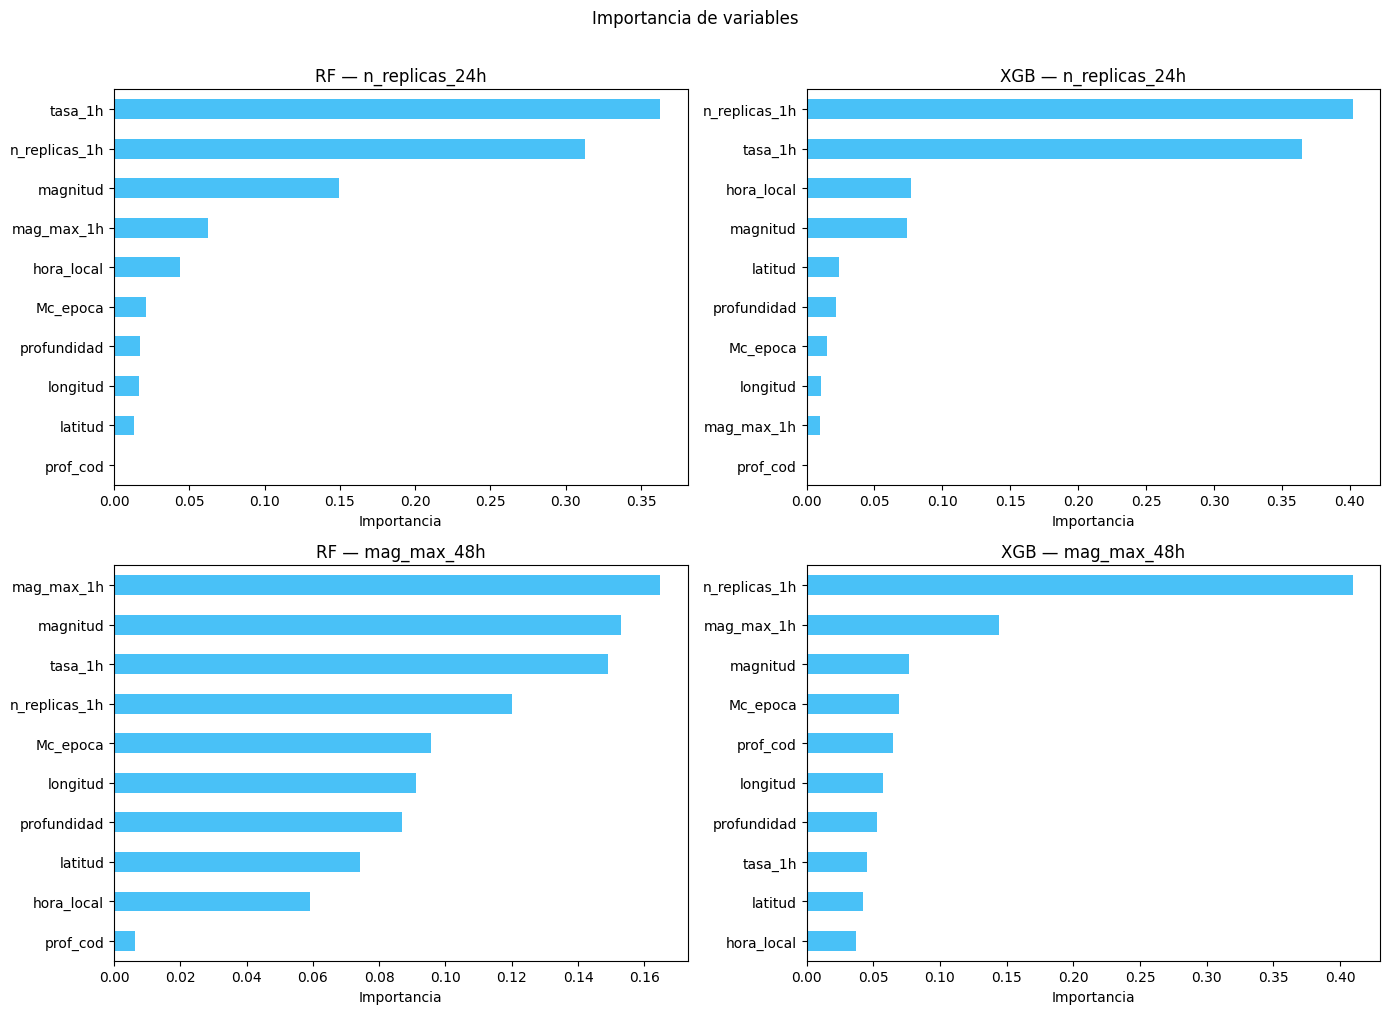

In [ ]:
# Entrenar en todo el corpus para obtener importancias definitivas
rf1.fit(X, y1);  xgb1.fit(X, y1)
rf2.fit(X, y2);  xgb2.fit(X, y2)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, model, title in zip(
    axes.flat,
    [rf1, xgb1, rf2, xgb2],
    ['RF — n_replicas_24h', 'XGB — n_replicas_24h',
     'RF — mag_max_48h', 'XGB — mag_max_48h']
):
    imp = pd.Series(model.feature_importances_, index=FEATURES).sort_values()
    imp.plot(kind='barh', ax=ax, color='#29b6f6', alpha=0.85)
    ax.set_title(title)
    ax.set_xlabel('Importancia')

plt.suptitle('Importancia de variables', y=1.01)
plt.tight_layout()
plt.savefig('importancia_variables.png', dpi=150, bbox_inches='tight')
plt.show()

## Predicho vs. real (scatter out-of-sample)

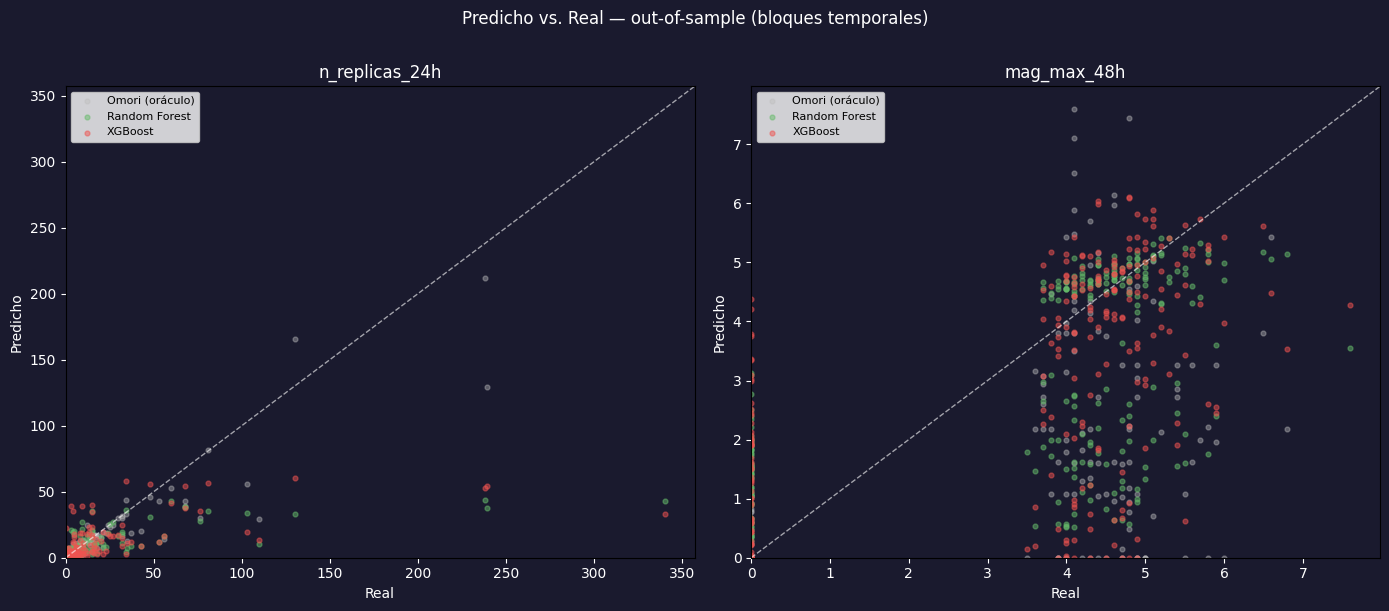

In [54]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, (real, pred_rf, pred_xgb, omori_p, label) in zip(axes, [
    (y1, pred_rf1, pred_xgb1, omori_pred_24, TARGET_1),
    (y2, pred_rf2, pred_xgb2, omori_pred_48, TARGET_2),
]):
    mask = ~np.isnan(pred_rf)
    lim  = max(real[mask].max(), pred_rf[mask].max(), pred_xgb[mask].max()) * 1.05

    ax.scatter(real[mask], omori_p[mask],   s=12, alpha=0.4, color='#bdbdbd', label='Omori (oráculo)')
    ax.scatter(real[mask], pred_rf[mask],   s=12, alpha=0.5, color='#66bb6a', label='Random Forest')
    ax.scatter(real[mask], pred_xgb[mask],  s=12, alpha=0.5, color='#ef5350', label='XGBoost')
    ax.plot([0, lim], [0, lim], 'white', linewidth=1, linestyle='--', alpha=0.6)
    ax.set_xlim(0, lim); ax.set_ylim(0, lim)
    ax.set_xlabel('Real'); ax.set_ylabel('Predicho')
    ax.set_title(label)
    ax.legend(fontsize=8)
    ax.set_facecolor('#1a1a2e')

fig.patch.set_facecolor('#1a1a2e')
for ax in axes:
    ax.tick_params(colors='white')
    ax.xaxis.label.set_color('white')
    ax.yaxis.label.set_color('white')
    ax.title.set_color('white')

plt.suptitle('Predicho vs. Real — out-of-sample (bloques temporales)', color='white', y=1.01)
plt.tight_layout()
plt.savefig('ml_pred_vs_real.png', dpi=150, facecolor=fig.get_facecolor(), bbox_inches='tight')
plt.show()

In [ ]:
# Serializar los 4 modelos base + modelo con feature Omori
joblib.dump(rf1, 'modelo_rf_24h.joblib')
joblib.dump(xgb1, 'modelo_xgb_24h.joblib')
joblib.dump(rf2, 'modelo_rf_mag48h.joblib')
joblib.dump(xgb2, 'modelo_xgb_mag48h.joblib')
joblib.dump(xgb1_omori, 'modelo_xgb_omori_24h.joblib')

# Ganadores canónicos (usados por el dashboard):
joblib.dump(xgb1_omori, 'modelo_mejor_24h.joblib')
joblib.dump(rf2, 'modelo_mejor_mag48h.joblib')

# Predicciones out-of-sample
resultados = mainshocks[['mainshock_id', 'datetime_utc', 'magnitud', 'n_replicas_24h', 'n_replicas_48h', 'mag_max_48h']].copy()
resultados['omori_pred_24h'] = omori_pred_24
resultados['rf_pred_24h'] = pred_rf1
resultados['xgb_pred_24h'] = pred_xgb1
resultados['xgb_omori_pred_24h']  = pred_xgb1_omori
resultados['omori_pred_48h'] = omori_pred_48
resultados['rf_pred_mag48h'] = pred_rf2
resultados['xgb_pred_mag48h'] = pred_xgb2
resultados.to_parquet('predicciones_ml.parquet', index=False)

print('Modelos guardados:')
for f in ['modelo_mejor_24h.joblib', 'modelo_mejor_mag48h.joblib', 'modelo_xgb_omori_24h.joblib']:
    print(f'  {f}  ({Path(f).stat().st_size/1e3:.0f} KB)')
print('predicciones_ml.parquet guardado.')

Modelos guardados:
  modelo_mejor_24h.joblib  (376 KB)
  modelo_mejor_mag48h.joblib  (2161 KB)
  modelo_xgb_omori_24h.joblib  (376 KB)
predicciones_ml.parquet guardado.
